# Машинное обучение. ВМК МГУ

# Практическое задание 5: SVM

## Уровень: **Исследовательский (Research)**

# О формате сдачи

🔷 При решении ноутбука используйте данный шаблон

```
✅ Можно добавлять новые ячейки любых типов
❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий
```

🔷 При оценивании задач учитывается код

```
✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно
```

🔷 При оценивании задач учитываются выводы

```
✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
✅ Сопутствующие изображения, графики, таблички - приветствуются!
❌ При отсутствии выводов задание не засчитается на полный балл
```

Цель данного задания:

- Изучите нюансы работы модели SVM
- Узнаете про метод, который позволяет понижать число признаков и изучите его особенности на практике
- Научитесь корректировать выход модели SVM-классификатора, чтобы уметь получать вероятности

**Примерное время выполнения (execution
time/время выполнения, если нажать run all) всех ячеек ноутбука при
правильной реализации: до 10 минут **

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, возможно, нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится

На скачивание файла и установку понадобится не более 5 минут.

**Важно!**

Устанавливать нужные версии нужно каждый раз, когда создается новый
рантайм. Например, если вы 2 часа подряд делаете это задание, то
подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в
понедельник, затем закрыли/выключили ноутбук, то при продолжении в
среду, вам нужно будет запустить рантайм заново и следовательно заново
установить библиотеки.

**Важно!**
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в соответствии с гайдом .pdf)

In [ ]:
# !!! Данный блок будет работать только в Google-Colab !!!
! gdown 10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
! pip install -r /content/requirements_2024_25_for_colab_small.txt

Downloading...
From: https://drive.google.com/uc?id=10k8Hwn9kpK9SpK4IEj4-EaWQZqgYT5-Q
To: /content/requirements_2024_25_for_colab_small.txt
100% 375/375 [00:00<00:00, 1.11MB/s]


Проверим версию библиотеки:

In [ ]:
import catboost
assert(catboost.__version__ == '1.2.7')

Теперь можно приступать к выполнению задания! :)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from copy import copy

Если Вы дальтоник, то можете воспользоваться готовой colormap из matplotlib (или найти свою):

```
plt.style.use('tableau-colorblind10')
```

In [ ]:
from matplotlib.colors import ListedColormap

from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score
from sklearn.datasets import make_blobs, make_circles, make_moons

In [ ]:
def make_moons_cls(size=1000, d=2):
    X, y = make_moons(n_samples=size, noise=0.15)
    if d > 2:
        X = np.concatenate((X, np.random.normal(size=(size, d-2))), axis=1)
    return X, y

def make_circles_cls():
    X, y = make_circles()

def generate_data_with_imb_classes(size1=100, size2=10):
    X = np.r_[(
        np.random.normal(loc=1.0, size=(size1, 2)),
        np.random.normal(loc=0.5, size=(size2, 2))
    )]

    y = np.ones(len(X))
    y[-size2:] = 0
    return X, y

In [ ]:
def plot_separating_surface(X, y, cls, view_support=False, title=''):
    x_min = min(X[:, 0]) - 0.1
    x_max = max(X[:, 0]) + 0.1
    y_min = min(X[:, 1]) - 0.1
    y_max = max(X[:, 1]) + 0.1
    h = 0.005
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
    Z = cls.predict(np.c_[xx.ravel(), yy.ravel()])

    plt.figure(figsize=(10, 10))
    if title:
        plt.title(title)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=40, cmap=cm_bright)
    if view_support:
        plt.scatter(X[cls.support_, 0], X[cls.support_, 1],
                    c=y[cls.support_], edgecolors='k', s=150, cmap=cm_bright)
    Z = Z.reshape(xx.shape)
    plt.xticks(())
    plt.yticks(())
    plt.contourf(xx, yy, Z, cmap=cm, alpha=.3)
    plt.show()

# Загрузка данных

In [ ]:
import gdown
gdown.download_folder('https://drive.google.com/drive/folders/1bp39_Jj0edo1lzxZ3DIoChsOVy5DVi1R?usp=sharing')

Retrieving folder contents


Retrieving folder 1tv605hGxdQtd4zC787DbcRF0312gDeK_ imbalanced
Processing file 14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u X_imb_test.npz.npy
Processing file 1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc X_imb.npz.npy
Processing file 1uD87Xbh4MMBBn5fsScrknI54SINIqory y_imb_test.npz.npy
Processing file 1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf y_imb.npz.npy
Retrieving folder 1uoI6vZWwIII1jd2k5TtsZTJ3JOkK0G6O public
Processing file 1Win7ZtHLHEbDtX6x6O7vBJHwJviQxbp5 cX_test.npy
Processing file 1MowPnLFAMEjjcAjDA4skE4OUFdmaiSY6 cX_train.npy
Processing file 1VYA4N5wCQhwteQSZkDogFTha2xRv0FgW cy_train.npy


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u
To: /content/05-SVM/imbalanced/X_imb_test.npz.npy
100%|██████████| 2.05k/2.05k [00:00<00:00, 5.37MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc
To: /content/05-SVM/imbalanced/X_imb.npz.npy
100%|██████████| 2.05k/2.05k [00:00<00:00, 5.75MB/s]
Downloading...
From: https://drive.google.com/uc?id=1uD87Xbh4MMBBn5fsScrknI54SINIqory
To: /content/05-SVM/imbalanced/y_imb_test.npz.npy
100%|██████████| 1.09k/1.09k [00:00<00:00, 3.29MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf
To: /content/05-SVM/imbalanced/y_imb.npz.npy
100%|██████████| 1.09k/1.09k [00:00<00:00, 2.84MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Win7ZtHLHEbDtX6x6O7vBJHwJviQxbp5
To: /content/05-SVM/public/cX_test.npy
100%|██████████| 8.13k/8

['/content/05-SVM/imbalanced/X_imb_test.npz.npy',
 '/content/05-SVM/imbalanced/X_imb.npz.npy',
 '/content/05-SVM/imbalanced/y_imb_test.npz.npy',
 '/content/05-SVM/imbalanced/y_imb.npz.npy',
 '/content/05-SVM/public/cX_test.npy',
 '/content/05-SVM/public/cX_train.npy',
 '/content/05-SVM/public/cy_train.npy']


Перед выполнение данного ноутбука рекомендуем просмотреть базовый ноутбук по SVM

# Форма разделяющей поверхности для несбалансированных классов

Формы разделяющих поверхностей могут быть вариативными для
нелинейного случая. Иногда, выбранная форма поверхности может плохо
подходить для целевого распределения объектов. Особенно это может быть
заметно, если соотношение классов в обучении отличается от тестового.
Такое свойственно медицинским данным, где в обучающих данных часто
наблюдается перекос в сторону больных, так как именно их данные чаще
собираются.

Давайте обучим SVC на несбалансированных данных и построим
разделяющую поверхность для тестовой выборки с другим соотношением
классов.

In [ ]:
X_distr1 = np.load('05-SVM/imbalanced/X_imb.npz.npy')
y_distr1 = np.load('05-SVM/imbalanced/y_imb.npz.npy')
X_distr2 = np.load('05-SVM/imbalanced/X_imb_test.npz.npy')
y_distr2 = np.load('05-SVM/imbalanced/y_imb_test.npz.npy')

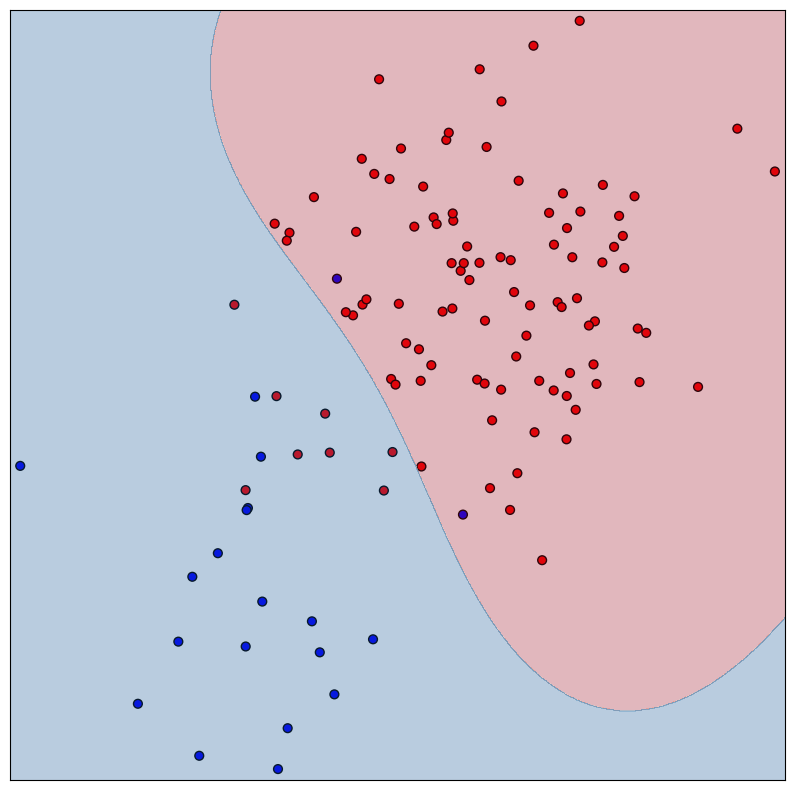

In [ ]:
# Модель с дефолтными параметрами, которую Вам предстоит улучшить
base_model = SVC()
base_model.fit(X_distr1, y_distr1)
plot_separating_surface(X_distr2, y_distr2, base_model)

## Так
как синих объектов было существенно больше в обучении, разделяющая
поверхность отнесла к этому классу большую часть пространства около
границы классов. При этом, из-за возросшего количества красных объектов в
тестовой выборке, многие из них стали ошибочно относиться к другому
классу.

Один
из способов исправить эту проблему - это повлиять на форму поверхности с
помощью задания весов классов, которые задаются через параметр
class_weight в sklearn.svm.SVC. Особенно это может быть полезно в
задачах, где известно, что распределение классов в обучающей выборке
отличается от реального.

## **Задание 1 [2 баллa]**

В данном задании вам будет дана выборка с несбалансированными данными. Кроме того, дана вторая выборка,
в которой классы имеют то же распределение, но классы имеют другое соотношение. Вам
нужно построить различные rbf-модели, меняя параметры весов классов и
визуализировать разделяющие поверхности. Попробуйте улучшить
качество на второй выборке (X_distr2, y_distr2), обучаясь только на
первой (X_distr1, y_distr1) меняя параметры весов классов относительно
дефолтных: class_weight={1: 1.0, 0: 1.0}. В качестве метрики, которую
нужно оптимизировать нужно использовать accuracy на (X_distr2, y_dist2).

In [ ]:
from itertools import product

In [ ]:
w1_best, w2_best = None, None
best_acc = 0
grid = [0.01, 0.1, 0.5, 1.0, 5, 10, 100, 1000]
for w1, w2 in product(grid, grid):
    svc_cls = SVC(C=1.0, class_weight={1: w1, 0: w2})
    svc_cls.fit(X_distr1, y_distr1)
    acc = accuracy_score(y_distr2, svc_cls.predict(X_distr2))
    # Save model with best accuracy
    # Your code here
    if acc > best_acc:
        w1_best, w2_best = w1, w2
        best_acc = acc


print(f'Weight1: {w1_best},\nWeight2: {w2_best},\nBest accuracy: {best_acc}')

Weight1: 0.1,
Weight2: 5,
Best accuracy: 0.9666666666666667


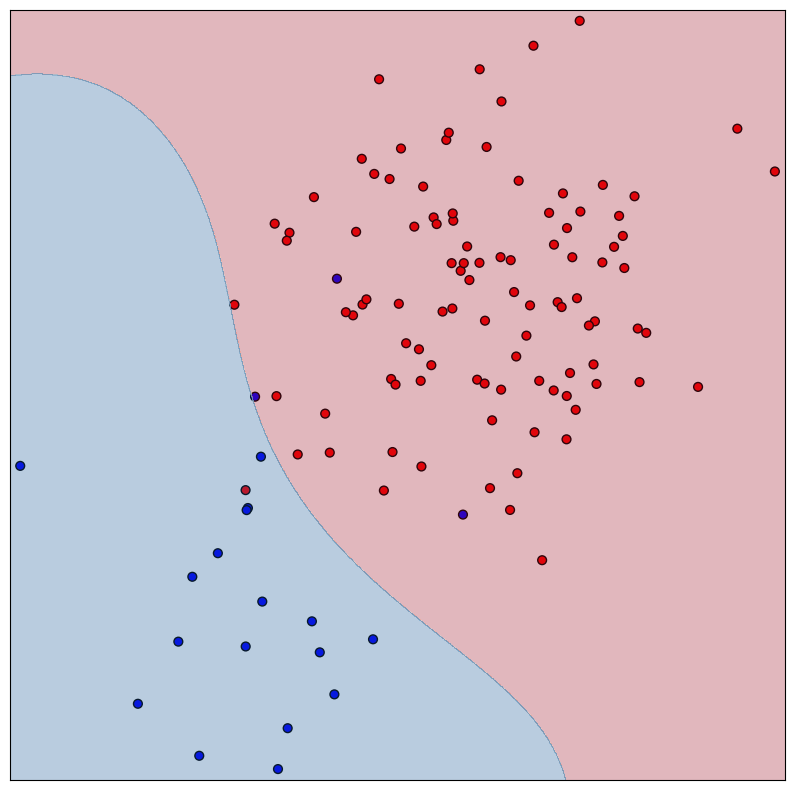

In [ ]:
# best_svc_cls = ...
# Your code here

best_svc_cls = SVC(C=1.0, class_weight={1: w1_best, 0: w2_best})
best_svc_cls.fit(X_distr1, y_distr1)
plot_separating_surface(X_distr2, y_distr2, best_svc_cls)

In [ ]:
print('My best classifier:')
print('Accuracy:', accuracy_score(y_distr2, best_svc_cls.predict(X_distr2)))

My best classifier:
Accuracy: 0.9666666666666667


# Ограничения SVM

В предыдущих заданиях мы убедились в мощности и гибкости моделей SVM.
Теперь ответим на вопрос, насколько реально обучить модель SVM на
выборках большого размера или с большим числом признаков. Нужно
провести два эксперимента.

## **Задание 2 [2 баллa]**

В
первом перебирать размер выборки
и для каждого запуска посчитать реальное время обучения модели. При
этом
делить выборку на обучение и тестирование не нужно. Также качество
обученной модели в данном эксперименте не имеет значение. Размеры
выборки предлагается перебирать в диапазоне range(1000, 10001, 1000) с
использованием generate_data_with_balanced_classes(size=n).

Необходимо сравнить время обучения SVM с логистической регрессией. Для этого
замеры повторите также для модели sklearn.linear_model.LogisticRegression. Время обучения одной модели замеряйте
с помощью стандартной библиотеки time (пример в ячейке ниже).

Вы можете поставить эксперименты и с большими выборками, чем предлагается в задании (сгенерировать их),
тогда эффект должен быть виден еще сильнее.

**Внимание!** во время замеров времени
работы, отключите сторонние процессы, занимающие CPU, иначе замеры
времени работы окажутся некорректными. Помните, что времени работы в
зависимости от числа данных и признаков должно меняться монотонно, без
ступенчатых изменений (за исключением небольшого шума).

In [ ]:
# Как замерять время
import time
time_start = time.time()
time.sleep(1) # Вместо этой команды - запуск замеряемого алгоритма
print("Время работы:", time.time() - time_start)

Время работы: 1.0023715496063232


In [ ]:
def generate_data_with_balanced_classes(size=500, d=2, noise_scale=0.1):
    X = np.random.normal(size=(size*2, d))
    mask = X[:, 1] ** 2 > X[:, 0] - 0.1 + np.random.normal(scale=noise_scale)
    y = np.ones(len(X))
    y[mask] = 0
    return X, y

In [ ]:
from sklearn.linear_model import LogisticRegression
svc_time = []
log_time = []
grid = [i for i in range (1000, 10001, 1000)]


for s in grid:
    xxx, yyy = generate_data_with_balanced_classes(s)
    svc_time_start = time.time()
    svc_cls = SVC(C=1.0, class_weight={1: w1, 0: w2})
    svc_cls.fit(xxx, yyy)
    svc_time.append(time.time() - svc_time_start)
    print(f'SVC_time with data size = {s} {svc_time[-1]}')

    log_time_start = time.time()
    log_cls = LogisticRegression(C=1.0, class_weight={1: w1, 0: w2})
    log_cls.fit(xxx, yyy)
    log_time.append(time.time() - log_time_start)
    print(f'LOG_time with data size = {s} {log_time[-1]}')

SVC_time with data size = 1000 0.02377629280090332
LOG_time with data size = 1000 0.006901741027832031
SVC_time with data size = 2000 0.04751873016357422
LOG_time with data size = 2000 0.008487462997436523
SVC_time with data size = 3000 0.06640768051147461
LOG_time with data size = 3000 0.021100759506225586
SVC_time with data size = 4000 0.0984349250793457
LOG_time with data size = 4000 0.029070615768432617
SVC_time with data size = 5000 0.14249777793884277
LOG_time with data size = 5000 0.022073745727539062
SVC_time with data size = 6000 0.17028331756591797
LOG_time with data size = 6000 0.022393465042114258
SVC_time with data size = 7000 0.25759053230285645
LOG_time with data size = 7000 0.029640674591064453
SVC_time with data size = 8000 0.28449034690856934
LOG_time with data size = 8000 0.040921688079833984
SVC_time with data size = 9000 0.31711626052856445
LOG_time with data size = 9000 0.04433155059814453
SVC_time with data size = 10000 0.3614330291748047
LOG_time with data size 

## **Задание 3 [2 баллa]**

Во втором эксперименте предлагается проделать то же самое, что и в
первом эксперименте, только меняя размерность пространства признаков.
Для этого можете воспользоваться функцией
generate_data_with_balanced_classes(dim=d). Признаки предлагается
перебирать по сетке range(10, 1001, 100) .

Постройте графики времени работы в зависимости от числа признаков для
SVM и логистической регрессии, сравните их и сделайте выводы.

**Подсказка** Придумывая обоснование получившимся результатам попробуйте использовать
вид решаемой задачи в SVM, который был дан вам на лекции.

In [ ]:
grid = [i for i in range (10, 1001, 100)]
svc_dim_time = []
log_dim_time = []

for d in grid:
    xxx, yyy = generate_data_with_balanced_classes(d=d)
    svc_time_start = time.time()
    svc_cls = SVC(C=1.0, class_weight={1: w1, 0: w2})
    svc_cls.fit(xxx, yyy)
    svc_dim_time.append(time.time() - svc_time_start)
    print(f'SVC_time with dim = {d} {svc_dim_time[-1]}')

    log_time_start = time.time()
    log_cls = LogisticRegression(C=1.0, class_weight={1: w1, 0: w2}, max_iter = 1000)
    log_cls.fit(xxx, yyy)
    log_dim_time.append(time.time() - log_time_start)
    print(f'LOG_time with dim = {d} {log_dim_time[-1]}')

SVC_time with dim = 10 0.07675480842590332
LOG_time with dim = 10 0.023910999298095703
SVC_time with dim = 110 0.28081655502319336
LOG_time with dim = 110 0.04697895050048828
SVC_time with dim = 210 0.31802845001220703
LOG_time with dim = 210 0.16521167755126953
SVC_time with dim = 310 0.6084446907043457
LOG_time with dim = 310 0.5378782749176025
SVC_time with dim = 410 0.7786483764648438
LOG_time with dim = 410 0.5690333843231201
SVC_time with dim = 510 0.7468662261962891
LOG_time with dim = 510 0.4189784526824951
SVC_time with dim = 610 0.8099980354309082
LOG_time with dim = 610 0.3130781650543213
SVC_time with dim = 710 0.7637627124786377
LOG_time with dim = 710 0.1676325798034668
SVC_time with dim = 810 0.508167028427124
LOG_time with dim = 810 0.18771743774414062
SVC_time with dim = 910 0.8876397609710693
LOG_time with dim = 910 0.321380615234375


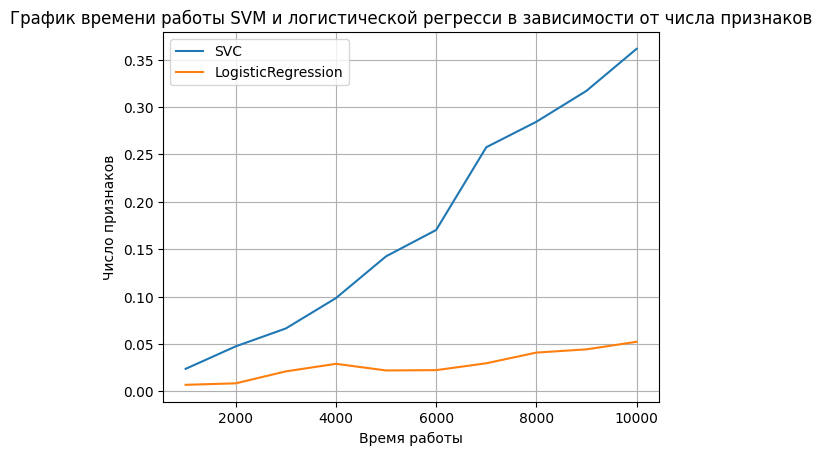

In [ ]:
plt.figure()
plt.title('График времени работы SVM и логистической регресси в зависимости от числа признаков')
plt.grid(True)
plt.xlabel('Время работы')
plt.ylabel("Число признаков")
plt.plot(list(range(1000,10001,1000)), svc_time, label='SVC')
plt.plot(list(range(1000,10001,1000)), log_time, label='LogisticRegression')
plt.legend()

**Логистическая регрессия является
линейным методом и требует меньше вычислений для обучения по сравнению с
нелинейной моделью, такой как SVM с rbf-ядром. В результате рост
времени работы происходит гораздо медленнее.**

# Уменьшение размерности входа

Если уменьшение числа объектов сложная и зачастую невозможная задача,
то
для понижения числа признаков существует стандартное решение. В
предыдущих заданиях Вы уже сталкивались с l1-регуляризацией, которая
позволяла уменьшить число признаков в задаче линейной
классификации/регрессии. Однако для большинства ML-алгоритмов такой
способ уменьшения числа признаков неприменим.

Зато существует стандартное для всех алгоритмов понижение размерности
входа. Данный алгоритм называется Principal Component Analysis (PCA,
метод главных компонент). Он находит такое линейное пространство меньшей
размерности $k$ ($k << d$, где d изначальная размерность входа),
проекция на которое теряет меньше всего информации. Подробнее об этом
можете почитать тут https://scikit-learn.org/stable/modules/decomposition.html#pca .

## **Задание 4 [2 баллa]**

Эксперимент: Проекция в очень малое число координат сильно "упрощает" выборку, из-за чего качество решения задачи может в итоге упасть. В
следующем эксперименте предлагается исследовать зависимость скорости
работы метода и качества решения задачи при использовании понижения
размерности. Требуется построить два графика:

1. График зависимости времени работы всего цикла обучения от числа признаков $k$, которое остается после применения PCA.
2. График зависимости качества решения (accuracy) задачи классификации
от числа признаков $k$, которое остается после применения PCA.

При этом под полным циклом обучения подразумевается обучение PCA +
обучение SVM. Данные для обучения: первые две координаты - "луны", а
остальные координаты, случайные.
Таким образом, без понижения размерности SVM с rbf ядром должен иметь
точность близкую к 100\%. Чтобы лучше
видеть эффект на графиках, можете менять размер генерируемой выборки.
Для данных размеров $k$ рекомендуется перебирать от 10 до 500 (тогда
будет видна требуемая закономерность).

**Обратите внимание!** Не забывайте
делить выборку на обучение и валидацию в этом эксперименте (так как мы
смотрим на качество, мы хотим считать его честно). При этом PCA как и
любой другой алгоритм ML тоже нельзя учить на тесте. Общая схема
применения PCA описана в ячейках ниже.

In [ ]:
X_moons, y_moons = make_moons_cls(2000, 1000)

In [ ]:
X_moons.shape

(2000, 1000)


In [ ]:
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.show()